In [1]:
import sys
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import modul internal proyek Anda
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_stock_data, dataset_splitting
from src.visualizer import plot_daily_candlestick, plot_interactive_candlestick
from src.features import create_features          # Sesuaikan nama fungsi jika berbeda
from src.label import create_labels                # Sesuaikan nama fungsi jika berbeda
from src.model_config import MODEL_CONFIGS         # Kamus konfigurasi model & grid
from src.modelling import TargetModellingPipeline  # Pipeline retraining per target
from src.risk_manager import evaluate_trade_risk   # Otak manajemen risiko kuantitatif
from src.backtest import WalkForwardBacktester

print("✓ Seluruh modul berhasil diimpor.")

✓ Seluruh modul berhasil diimpor.


In [2]:
# 1. Unduh Data Historis Saham
ticker_target = "BUMI.JK"
start_date = "2014-11-01"
end_date = "2025-06-30"
end_date_today = datetime.now().strftime('%Y-%m-%d')

df_bumi = load_stock_data(ticker=ticker_target, start_date=start_date, end_date=end_date_today)

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 2900 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 123 baris data (NaN atau Volume 0).
Berhasil memuat 2777 baris data bersih untuk BUMI.JK.


In [3]:

plot_interactive_candlestick(df=df_bumi, ticker_name="BUMI", start_date="2024-01-01", end_date="2024-12-31")

In [4]:
# 2. Replikasi Rekayasa Fitur (X) & Target Label (y)
df_features = create_features(df_bumi.copy()) # Panggil fungsi dari features.py
df_labels = create_labels(df_bumi.copy())     # Panggil fungsi dari label.py

# Ekstrak daftar kolom fitur (mengabaikan kolom NaN)
feature_cols = [col for col in df_features.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume']]

# 3. Pisahkan Data ke Fase In-Sample & Out-of-Sample menggunakan dataset_splitting
X_in, y_in_raw, X_oos, y_oos_raw, _, _ = dataset_splitting(df_features, df_labels)

# Bungkus dictionary target label untuk memfasilitasi 5 model
y_in_dict = {target: y_in_raw[target] for target in ['trend_slope', 'return', 'risk', 'days_to_max', 'days_to_min']}
y_oos_dict = {target: y_oos_raw[target] for target in ['trend_slope', 'return', 'risk', 'days_to_max', 'days_to_min']}

# 4. Inisialisasi & Jalankan Backtest
backtester = WalkForwardBacktester(
    ticker=ticker_target,
    initial_capital=5_000_000.0,
    max_risk_pct=0.06,
    max_alloc_pct=0.5,
    fee_buy=0.0015,
    fee_sell=0.0025,
    min_rr_ratio=1.1
)

# Jalankan simulasi pada data Out-of-Sample (2024 - 2025)
df_trades_result, df_equity_curve = backtester.run_backtest(
    X_in=X_in,
    y_in_dict=y_in_dict,
    X_oos=X_oos,
    y_oos_dict=y_oos_dict,
    df_raw_prices=df_bumi,
    feature_cols=feature_cols
)

 MEMULAI SIMULASI WALK-FORWARD ANALYSIS (BUMI.JK)
 Modal Awal: Rp5,000,000.00

[INIT] Memuat model awal dari folder models/bumi...
--------------------------------------------------
PERIODE KELOLAAN: 2024-01 | Ukuran Data OOS: 22 Hari Bursa
--------------------------------------------------
[RETRAIN] Bulan pertama Out-of-Sample: menggunakan model awal tanpa retrain.
--------------------------------------------------
PERIODE KELOLAAN: 2024-02 | Ukuran Data OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 5 model dengan data Expanding Window (2141 baris)...
[RETRAIN] Seluruh 5 model berhasil diperbarui.

--------------------------------------------------
PERIODE KELOLAAN: 2024-03 | Ukuran Data OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 5 model dengan data Expanding Window (2159 baris)...
[RETRAIN] Seluruh 5 model berhasil diperbarui.

--------------------------------------------------
PERIOD

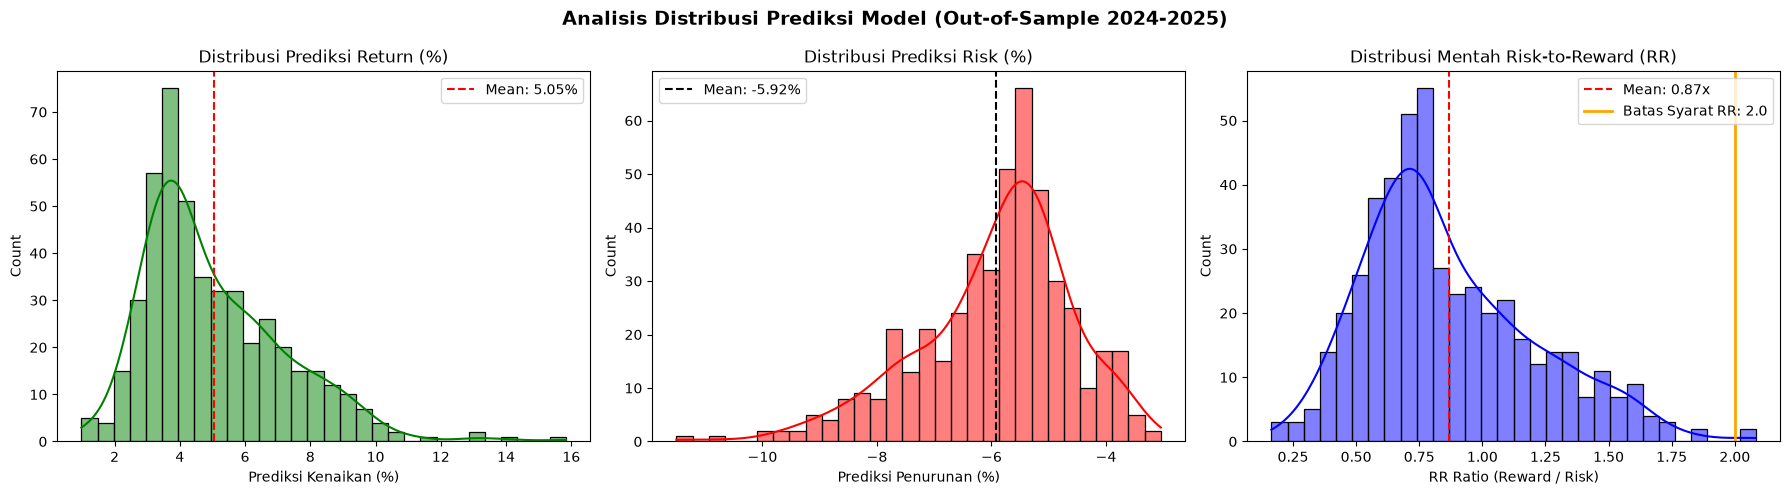

=== STATISTIK PREDIKSI MODEL ===
                     mean       std        min       50%        max
pred_return_pct  5.052170  2.170515   0.982721  4.442820  15.830312
pred_risk_pct   -5.916461  1.338120 -11.501744 -5.686114  -3.043235
raw_rr_ratio     0.865944  0.339054   0.164332  0.785179   2.083013


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Ekstrak model awal dari objek backtester yang sudah diinisialisasi
model_return = backtester.trained_pipelines['return']
features_return = backtester.features_used['return']

model_risk = backtester.trained_pipelines['risk']
features_risk = backtester.features_used['risk']

# 2. Lakukan prediksi massal pada seluruh data Out-of-Sample (X_oos)
# Drop baris NaN agar dimensi sesuai saat di-predict
X_oos_clean_ret = X_oos.dropna(subset=features_return)
X_oos_clean_risk = X_oos.dropna(subset=features_risk)

# Menyamakan index agar bisa digabung (ambil irisan index yang valid)
valid_idx = X_oos_clean_ret.index.intersection(X_oos_clean_risk.index)

pred_returns = model_return.predict(X_oos.loc[valid_idx, features_return])
pred_risks = model_risk.predict(X_oos.loc[valid_idx, features_risk])

# 3. Buat DataFrame khusus untuk analisis distribusi
df_dist = pd.DataFrame({
    'pred_return_pct': pred_returns * 100, # Jadikan persentase
    'pred_risk_pct': pred_risks * 100      # Jadikan persentase
}, index=valid_idx)

# Asumsi risiko tidak boleh 0 agar tidak error saat pembagian
df_dist['pred_risk_pct'] = df_dist['pred_risk_pct'].replace(0, -0.01)

# Hitung Rasio Risk-to-Reward Mentah (Tanpa Fee)
# Karena risk bernilai negatif, kita gunakan abs()
df_dist['raw_rr_ratio'] = df_dist['pred_return_pct'] / df_dist['pred_risk_pct'].abs()

# 4. Visualisasi Distribusi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle("Analisis Distribusi Prediksi Model (Out-of-Sample 2024-2025)", fontsize=14, fontweight='bold')

# Plot 1: Distribusi Prediksi Return
sns.histplot(df_dist['pred_return_pct'], bins=30, kde=True, ax=axes[0], color='green')
axes[0].set_title('Distribusi Prediksi Return (%)')
axes[0].set_xlabel('Prediksi Kenaikan (%)')
axes[0].axvline(df_dist['pred_return_pct'].mean(), color='red', linestyle='--', label=f"Mean: {df_dist['pred_return_pct'].mean():.2f}%")
axes[0].legend()

# Plot 2: Distribusi Prediksi Risk
sns.histplot(df_dist['pred_risk_pct'], bins=30, kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribusi Prediksi Risk (%)')
axes[1].set_xlabel('Prediksi Penurunan (%)')
axes[1].axvline(df_dist['pred_risk_pct'].mean(), color='black', linestyle='--', label=f"Mean: {df_dist['pred_risk_pct'].mean():.2f}%")
axes[1].legend()

# Plot 3: Distribusi Risk-to-Reward Ratio (RR)
# Batasi nilai maksimum x agar grafik tidak rusak karena outlier pembagian tak terhingga
sns.histplot(df_dist['raw_rr_ratio'][df_dist['raw_rr_ratio'] < 10], bins=30, kde=True, ax=axes[2], color='blue')
axes[2].set_title('Distribusi Mentah Risk-to-Reward (RR)')
axes[2].set_xlabel('RR Ratio (Reward / Risk)')
axes[2].axvline(df_dist['raw_rr_ratio'].mean(), color='red', linestyle='--', label=f"Mean: {df_dist['raw_rr_ratio'].mean():.2f}x")
axes[2].axvline(2.0, color='orange', linestyle='-', linewidth=2, label="Batas Syarat RR: 2.0")
axes[2].legend()

plt.tight_layout()
plt.show()

# 5. Tampilkan Statistik Deskriptif
print("=== STATISTIK PREDIKSI MODEL ===")
print(df_dist.describe().T[['mean', 'std', 'min', '50%', 'max']])

In [6]:
# Menampilkan grafik interaktif yang berisi Candlestick, Volume, dan Hasil Prediksi
plot_interactive_candlestick(
    df=df_bumi,               # Dataframe OHLCV saham (sesuaikan nama variabel jika berbeda)
    ticker_name=ticker_target,
    start_date="2024-01-01",  # Opsional: sesuaikan rentang zoom awal jika diperlukan
    end_date="2025-12-31",
    predictions_df=backtester.predictions_df,  # Ambil data dari objek backtester
    equity_curve_df=df_equity_curve,           # Diambil dari output run_backtest()
    trades_df=df_trades_result                 # Diambil dari output run_backtest()
)


In [7]:
final_equity = df_equity_curve.iloc[-1]['total_equity']
save_csv_path="../data/processed/jurnal_trading_final_equity_.csv"
df_journal = backtester.generate_journal(df_bumi, save_csv_path)

# Tampilkan jurnal
display(df_journal)


[INFO] Jurnal berhasil disimpan ke: ../data/processed/jurnal_trading.csv


,Open,High,Low,Close,Volume,Keputusan,Harga Eksekusi,Lot,Value Transaksi,Invested,Sisa Cash,Total Equity
Date,,,,,,,,,,,,
2024-01-02,85.00,97.00,85.00,95.00,"998,119,800",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-03,94.00,103.00,94.00,98.00,"2,186,067,200",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-04,99.00,101.00,97.00,99.00,"777,595,600",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-05,99.00,102.00,98.00,99.00,"486,296,200",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-08,100.00,100.00,95.00,97.00,"383,167,000",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,348.00,394.00,346.00,394.00,"12,257,775,400",-,0.00,0,0.00,0.00,"5,448,402.90","5,448,402.90"
2025-12-23,402.00,406.00,376.00,380.00,"8,335,353,200",-,0.00,0,0.00,0.00,"5,448,402.90","5,448,402.90"
2025-12-24,382.00,384.00,360.00,362.00,"4,795,205,000",-,0.00,0,0.00,0.00,"5,448,402.90","5,448,402.90"


In [8]:
list_rr = [1.0, 1.1, 1.3, 1.5, 1.7]
list_risk = [0.02, 0.03, 0.05, 0.06]

best_return = -999
best_params = {}
history = []

for rr in list_rr:
    for risk in list_risk:
        # Ubah parameter tester
        backtester.max_risk_percentage = risk
        backtester.max_alloc_pct = 0.5
        backtester.min_rr_ratio = rr
        
        # Jalankan ulang simulasi (pastikan Anda tidak me-reset model yang sudah di-train)
        # Jika Anda memodifikasi backtest.py agar ada fitur bypass training, ini akan sangat cepat
        df_trades, df_eq = backtester.run_backtest(
            X_in=X_in,
            y_in_dict=y_in_dict,
            X_oos=X_oos,
            y_oos_dict=y_oos_dict,
            df_raw_prices=df_bumi,
            feature_cols=feature_cols
        )
        
        final_equity = df_eq.iloc[-1]['total_equity']
        print(f"RR: {rr}, Risk: {risk} -> Final Equity: Rp{final_equity:,.2f}")

        data_baru = {
            'total_equity': f"{final_equity:,.2f}",
            'params': {'rr': rr, 'risk': risk}
        }
        history.append(data_baru)
        
        if final_equity > best_return:
            best_return = final_equity
            best_params = {'rr': rr, 'risk': risk}

print(history)
print(f"Parameter Terbaik: {best_params}")
print(f"RR: {rr}, Risk: {risk} -> Final Equity (Best Return): Rp{best_return:,.2f}")


 MEMULAI SIMULASI WALK-FORWARD ANALYSIS (BUMI.JK)
 Modal Awal: Rp5,000,000.00

[INIT] Memuat model awal dari folder models/bumi...
--------------------------------------------------
PERIODE KELOLAAN: 2024-01 | Ukuran Data OOS: 22 Hari Bursa
--------------------------------------------------
[RETRAIN] Bulan pertama Out-of-Sample: menggunakan model awal tanpa retrain.
--------------------------------------------------
PERIODE KELOLAAN: 2024-02 | Ukuran Data OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 5 model dengan data Expanding Window (2141 baris)...
[RETRAIN] Seluruh 5 model berhasil diperbarui.

--------------------------------------------------
PERIODE KELOLAAN: 2024-03 | Ukuran Data OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 5 model dengan data Expanding Window (2159 baris)...
[RETRAIN] Seluruh 5 model berhasil diperbarui.

--------------------------------------------------
PERIOD

In [9]:
print(history)

for i in history:
    print(i)

[{'total_equity': '5,448,402.90', 'params': {'rr': 1.0, 'risk': 0.02}}, {'total_equity': '5,448,402.90', 'params': {'rr': 1.0, 'risk': 0.03}}, {'total_equity': '5,448,402.90', 'params': {'rr': 1.0, 'risk': 0.05}}, {'total_equity': '5,448,402.90', 'params': {'rr': 1.0, 'risk': 0.06}}, {'total_equity': '5,483,288.85', 'params': {'rr': 1.1, 'risk': 0.02}}, {'total_equity': '5,483,288.85', 'params': {'rr': 1.1, 'risk': 0.03}}, {'total_equity': '5,483,288.85', 'params': {'rr': 1.1, 'risk': 0.05}}, {'total_equity': '5,483,288.85', 'params': {'rr': 1.1, 'risk': 0.06}}, {'total_equity': '5,085,057.75', 'params': {'rr': 1.3, 'risk': 0.02}}, {'total_equity': '5,085,057.75', 'params': {'rr': 1.3, 'risk': 0.03}}, {'total_equity': '5,085,057.75', 'params': {'rr': 1.3, 'risk': 0.05}}, {'total_equity': '5,085,057.75', 'params': {'rr': 1.3, 'risk': 0.06}}, {'total_equity': '4,959,823.70', 'params': {'rr': 1.5, 'risk': 0.02}}, {'total_equity': '4,959,823.70', 'params': {'rr': 1.5, 'risk': 0.03}}, {'tot

In [7]:
backtester.max_risk_percentage = 0.06
backtester.max_alloc_pct = 0.5
backtester.min_rr_ratio = 1.1

# Jalankan ulang simulasi (pastikan Anda tidak me-reset model yang sudah di-train)
# Jika Anda memodifikasi backtest.py agar ada fitur bypass training, ini akan sangat cepat
df_trades, df_eq = backtester.run_backtest(
    X_in=X_in,
    y_in_dict=y_in_dict,
    X_oos=X_oos,
    y_oos_dict=y_oos_dict,
    df_raw_prices=df_bumi,
    feature_cols=feature_cols
)

 MEMULAI SIMULASI WALK-FORWARD ANALYSIS (BUMI.JK)
 Modal Awal: Rp5,000,000.00

[INIT] Memuat model awal dari folder models/bumi...
--------------------------------------------------
PERIODE KELOLAAN: 2024-01 | Ukuran Data OOS: 22 Hari Bursa
--------------------------------------------------
[RETRAIN] Bulan pertama Out-of-Sample: menggunakan model awal tanpa retrain.
--------------------------------------------------
PERIODE KELOLAAN: 2024-02 | Ukuran Data OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 5 model dengan data Expanding Window (2141 baris)...
[RETRAIN] Seluruh 5 model berhasil diperbarui.

--------------------------------------------------
PERIODE KELOLAAN: 2024-03 | Ukuran Data OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 5 model dengan data Expanding Window (2159 baris)...
[RETRAIN] Seluruh 5 model berhasil diperbarui.

--------------------------------------------------
PERIOD

In [11]:
save_csv_path=f"../data/processed/jurnal_trading_{backtester.max_risk_percentage}_{backtester.max_alloc_pct}_{backtester.min_rr_ratio}.csv"
df_journal = backtester.generate_journal(df_bumi, save_csv_path)

# Tampilkan jurnal
display(df_journal)


[INFO] Jurnal berhasil disimpan ke: ../data/processed/jurnal_trading_0.06_0.5_1.1.csv


,Open,High,Low,Close,Volume,Keputusan,Harga Eksekusi,Lot,Value Transaksi,Invested,Sisa Cash,Total Equity
Date,,,,,,,,,,,,
2024-01-02,85.00,97.00,85.00,95.00,"998,119,800",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-03,94.00,103.00,94.00,98.00,"2,186,067,200",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-04,99.00,101.00,97.00,99.00,"777,595,600",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-05,99.00,102.00,98.00,99.00,"486,296,200",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-08,100.00,100.00,95.00,97.00,"383,167,000",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,348.00,394.00,346.00,394.00,"12,257,775,400",-,0.00,0,0.00,0.00,"5,483,288.85","5,483,288.85"
2025-12-23,402.00,406.00,376.00,380.00,"8,335,353,200",-,0.00,0,0.00,0.00,"5,483,288.85","5,483,288.85"
2025-12-24,382.00,384.00,360.00,362.00,"4,795,205,000",-,0.00,0,0.00,0.00,"5,483,288.85","5,483,288.85"


In [8]:
# Menampilkan grafik interaktif yang berisi Candlestick, Volume, dan Hasil Prediksi
plot_interactive_candlestick(
    df=df_bumi,               # Dataframe OHLCV saham (sesuaikan nama variabel jika berbeda)
    ticker_name=ticker_target,
    start_date="2024-01-01",  # Opsional: sesuaikan rentang zoom awal jika diperlukan
    end_date="2025-12-31",
    predictions_df=backtester.predictions_df,  # Ambil data dari objek backtester
    equity_curve_df=df_eq,           # Diambil dari output run_backtest()
    trades_df=df_trades                 # Diambil dari output run_backtest()
)


=== DISTRIBUSI ALASAN JUAL ===


exit_reason
Time-Stop      6
Take Profit    5
Stop Loss      2
Name: count, dtype: int64


Dalam bentuk persentase:


exit_reason
Time-Stop      46.153846
Take Profit    38.461538
Stop Loss      15.384615
Name: proportion, dtype: float64


=== DISTRIBUSI HARI UNTUK TIME-STOP ===


days_held
1     1
2     3
10    2
Name: count, dtype: int64

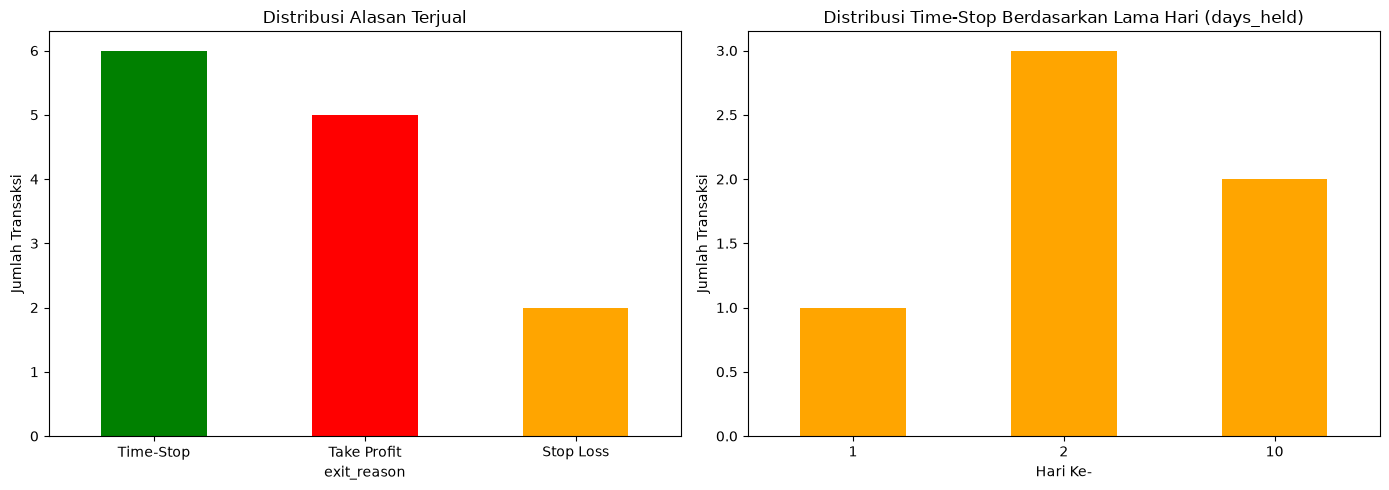

In [13]:
# 1. Melihat Distribusi Alasan Terjual (Exit Reason)
print("=== DISTRIBUSI ALASAN JUAL ===")
display(df_trades['exit_reason'].value_counts())
print("\nDalam bentuk persentase:")
display(df_trades['exit_reason'].value_counts(normalize=True) * 100)

# 2. Melihat Distribusi Hari untuk status 'Time-Stop'
print("\n=== DISTRIBUSI HARI UNTUK TIME-STOP ===")
time_stop_df = df_trades[df_trades['exit_reason'] == 'Time-Stop']
display(time_stop_df['days_held'].value_counts().sort_index())

# Opsional: Jika ingin divisualisasikan dalam bentuk grafik (Bar Chart)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Alasan Terjual
df_trades['exit_reason'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red', 'orange', 'grey'])
axes[0].set_title('Distribusi Alasan Terjual')
axes[0].set_ylabel('Jumlah Transaksi')
axes[0].tick_params(axis='x', rotation=0)

# Plot Hari Time-Stop
if not time_stop_df.empty:
    time_stop_df['days_held'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='orange')
    axes[1].set_title('Distribusi Time-Stop Berdasarkan Lama Hari (days_held)')
    axes[1].set_xlabel('Hari Ke-')
    axes[1].set_ylabel('Jumlah Transaksi')
    axes[1].tick_params(axis='x', rotation=0)
else:
    axes[1].set_title('Tidak Ada Transaksi Time-Stop')

plt.tight_layout()
plt.show()
